<a href="https://colab.research.google.com/github/omarpb03/Deep_learning/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Descargamos los datos (Keras lo guarda en caché automáticamente la primera vez)
(x_train, _), (x_test, _) = fashion_mnist.load_data()
import numpy as np
todas_las_imagenes = np.concatenate([x_train, x_test], axis=0)
# Convertir a float32 para la división
todas_las_imagenes = todas_las_imagenes.astype('float32')

# Normalizar los datos al rango [-1, 1]
todas_las_imagenes = (todas_las_imagenes - 127.5) / 127.5

# Añadir la dimensión del canal (para imágenes en escala de grises es 1)
# El resultado será un tensor de forma (70000, 28, 28, 1)
todas_las_imagenes = np.expand_dims(todas_las_imagenes, axis=-1)

print(f"Forma del dataset listo para la GAN: {todas_las_imagenes.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Forma del dataset listo para la GAN: (70000, 28, 28, 1)


In [ ]:
tf.random.set_seed(42)

#espacio latente
codings_size = 30

Dense = tf.keras.layers.Dense

#arquitectura para el generador
generador = tf.keras.Sequential([
    Dense(100, activation='relu', kernel_initializer='he_normal'),
    Dense(150, activation='relu', kernel_initializer='he_normal'),
    Dense(28 * 28, activation='tanh'),     # Se cambia a tanh para coincidir con el rango [-1, 1] de los datos reales
    tf.keras.layers.Reshape([28, 28, 1])   # Se agrega la dimensión del canal (1)
])
#arquitectura para el discriminante

discriminator = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    Dense(150, activation='relu', kernel_initializer='he_normal'),
    Dense(100, activation='relu', kernel_initializer='he_normal'),
    Dense(1, activation='sigmoid')

])

#GAN primero aplica el generador y luego el discriminante
gan = tf.keras.Sequential([generador, discriminator])



In [ ]:
discriminator.compile(loss='binary_crossentropy', optimizer='rmsprop')
discriminator.trainable = False
gan.compile(loss='binary_crossentropy', optimizer='rmsprop')

La primer fase es estimar los pesos del discriminante.  
En la segunda fase, se obtienen los pesos del generador, esto es en el ajuste del modelos GAN. En esta fase ya no se entrenan los pesos del discriminante, por eso se da la instruccion de FALSE.

In [ ]:
#el entrenamiento, al ser distinto, requiere definir un proceso especial

batch_size = 32
# Usamos el array ya preprocesado y normalizado
dataset = tf.data.Dataset.from_tensor_slices(todas_las_imagenes).shuffle(buffer_size=1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)
dataset

<_PrefetchDataset element_spec=TensorSpec(shape=(32, 28, 28, 1), dtype=tf.float32, name=None)>

In [ ]:
import matplotlib.pyplot as plt

def plot_multiple_images(images, n_cols=None):
  n_cols = n_cols or len(images)
  n_rows = (len(images) - 1) // n_cols + 1
  if images.shape[-1] == 1:
    images = np.squeeze(images, axis=-1) # Solo agregamos la variable 'images' al inicio)
  plt.figure(figsize=(n_cols, n_rows))
  for index, image in enumerate(images):
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

In [ ]:
#funcion que depende del modelo gan, datos, batch_size, tamano del espacio latente y numero de epochs

def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
  #separamos el generador y el discriminante
  for epoch in range(n_epochs):
    print(f"Epoch {epoch + 1}/{n_epochs}")
    for x_batch in dataset:
      #se genera el espacio latente
      #fase 1: entrenamos el discriminante
      #se genera un vector aleatorio Gaussiano por cada batch de dimension la del espacio latente
      noise = tf.random.normal(shape=[batch_size, codings_size])
      #se aplica el generador sobre los valores generados
      generated_images = generador(noise)
      #imagenes generadas por batch
      x_fake_and_real = tf.concat([generated_images, x_batch], axis=0)
      #al output del discriminante le corresponde 0 en todas las imagenes generadas
      #o 1 en las imagenes reales
      y1 = tf.constant([[0.]]*batch_size + [[1.]]*batch_size)
      #se entrena el discriminante

      discriminator.train_on_batch(x_fake_and_real, y1)

      #fase 2: entrenar el generador
      noise = tf.random.normal(shape=[batch_size, codings_size])
      y2 = tf.constant([[1.]]*batch_size)#enganar al discriminante diciendo que son reales
      #obtener los pesos del generador a partir de las perdidas del discriminante
      gan.train_on_batch(noise, y2)

  plot_multiple_images(generated_images.numpy(), 8)
  plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20


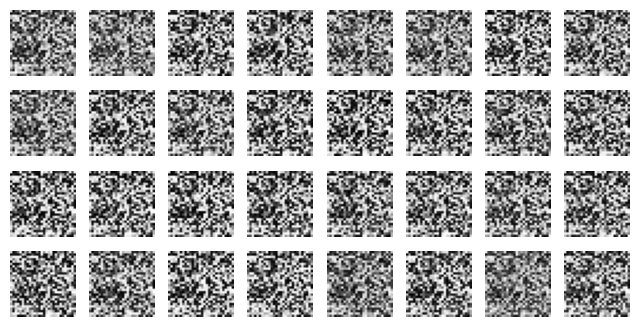

In [ ]:
# Entrenar por 50 épocas para que el modelo tenga tiempo de aprender los patrones
train_gan(gan, dataset, batch_size, codings_size, 20)
